In [ ]:
"""
Steps for colour palette extraction:
(1) get all images into the same space/size
(2) find clusters of similarly coloured pixels
(2) find KMeans clusters of similarly coloured pixels
(3) define BCTs in RBG values\n",
(4) create rules for black and white (use HSV)
(5) Use LAB to classify the colours
"""

In [ ]:
#### Art image dataset-> This is also in the github repo

image_folder = "capstone_art_dataset"

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from skimage.color import rgb2lab

In [ ]:
##Use CV2 to read and resize the image.6 colour palette being extracted. Returning the percentage of the dominant colours.

def dominant_colours(image_path, n_colours=6):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize for speed
    image = cv2.resize(image, (200, 200))

    pixels = image.reshape((-1, 3))

    # guard against images with fewer unique colours than clusters
    k = min(n_colours, len(np.unique(pixels, axis=0)))

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(pixels)

    counts = np.bincount(labels)
    centres = kmeans.cluster_centers_

    # Sort from most to least common
    order = np.argsort(counts)[::-1]

    dominant = centres[order].astype(int)
    proportions = counts[order] / counts.sum()   # fraction of the canvas per cluster

    return dominant, proportions

In [ ]:
### trying to figure out what RGB values go to which BCT ->
### This is sort of a sisyphean task as colour is relative to our perception and the quality of the photos is likely not white balanced
### iterations were done for colours that were not correctly identified
BCT_RGB = {
    "black":  [[0,0,0],[25,25,25],[45,45,45]],
    "white":  [[255,255,255],[245,245,240],[238,232,240]],
    "gray":   [[128,128,128],[95,95,95],[165,165,165],[190,185,190]],
    "red":    [[220,20,60],[139,0,0],[178,34,34],[110,25,45],[150,40,60],[128,40,55],[165,50,70]],
    "green":  [[0,128,0],[34,139,34],[85,107,47],[60,90,60],[107,142,90],[40,80,40]],
    "yellow": [[255,215,0],[240,230,140],[204,180,60],[180,160,80]],
    "blue":   [[30,144,255],[0,0,139],[70,130,180],[60,80,140],[90,110,160],[40,60,110]],
    "brown":  [[139,69,19],[160,82,45],[101,67,33],[120,90,70],[90,70,55],[150,110,80]],
    "orange": [[255,140,0],[255,165,0],[210,105,30],[200,120,60],[220,150,90]],
    "pink":   [[255,105,180],[255,182,193],[219,112,147],[200,140,165],[210,160,180],[230,170,190]],
    "purple": [[128,0,128],[75,0,130],[147,112,219],[110,70,110],[100,60,95],[130,90,140],[90,55,90],[150,100,150],
               [181,169,187],[160,147,172],[134,121,146],[175,160,180],[150,140,160]],
}

In [ ]:
# converting from RGB values to LAB values (more accureate for perception)

BCT_LAB = {}

for name, rgb_list in BCT_RGB.items():
    labs = []
    for rgb in rgb_list:
        rgb = np.array(rgb) / 255
        lab = rgb2lab(rgb.reshape(1, 1, 3))[0, 0]
        labs.append(lab)
    BCT_LAB[name] = labs

In [ ]:
### using HSV to check for black and white

import colorsys

def classify_colour(rgb):
    r, g, b = [float(v) for v in rgb]
    h, s, v = colorsys.rgb_to_hsv(r/255, g/255, b/255)

    # guardrails for black and white
    if v < 0.16:
        return "black"
    if s < 0.12:
        return "white" if v > 0.82 else ("gray" if v > 0.20 else "black")

#Otherwise use LAB to check for the colours and return it's closest BCT
    lab = rgb2lab((np.array(rgb)/255).reshape(1, 1, 3))[0, 0]
    best_name, best_dist = None, np.inf
    for name, prototypes in BCT_LAB.items():
        for prototype in prototypes:
            d = np.linalg.norm(lab - prototype)
            if d < best_dist:
                best_dist, best_name = d, name
    return best_name

In [ ]:
### fine the photos and create dataframe with labels
BCT_NAMES = list(BCT_RGB.keys())
results = []

for filename in sorted(os.listdir(image_folder)):

    if filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif")):

        path = os.path.join(image_folder, filename)

        colours, proportions = dominant_colours(path)


        digits = "".join(ch for ch in os.path.splitext(filename)[0] if ch.isdigit())
        row = {"image": filename, "num": int(digits) if digits else None}

        # use clusters to take the percentage of the colour dominating the images.
        bct_pct = {name: 0.0 for name in BCT_NAMES}

        for i, (colour, prop) in enumerate(zip(colours, proportions)):
            name = classify_colour(colour)
            row[f"RGB_{i+1}"] = tuple(int(v) for v in colour)
            row[f"BCT_{i+1}"] = name
            row[f"PCT_{i+1}"] = round(float(prop) * 100, 1)
            bct_pct[name] += float(prop) * 100

        # one column per basic colour term
        for name in BCT_NAMES:
            row[f"pct_{name}"] = round(bct_pct[name], 1)

        # readable palette string + dominant term
        present = sorted(bct_pct.items(), key=lambda x: -x[1])
        row["palette"] = "; ".join(f"{n} {round(p)}%" for n, p in present if p >= 3)
        row["dominant_bct"] = present[0][0] if present else ""

        results.append(row)

df = pd.DataFrame(results)
df.head()

,image,num,RGB_1,BCT_1,PCT_1,RGB_2,BCT_2,PCT_2,RGB_3,BCT_3,...,pct_red,pct_green,pct_yellow,pct_blue,pct_brown,pct_orange,pct_pink,pct_purple,palette,dominant_bct
0,1.jpg,1,"(245, 233, 247)",white,74.5,"(107, 61, 98)",purple,5.8,"(91, 20, 43)",red,...,10.4,0.0,0.0,0.0,0.0,0.0,0.0,15.1,white 74%; purple 15%; red 10%,white
1,10.jpg,10,"(214, 184, 148)",gray,24.8,"(228, 210, 185)",white,23.0,"(166, 148, 130)",gray,...,0.0,0.0,0.0,0.0,19.1,0.0,0.0,0.0,gray 42%; white 23%; brown 19%; black 15%,gray
2,100.jpg,100,"(49, 84, 63)",green,57.9,"(252, 242, 76)",yellow,17.7,"(44, 50, 41)",black,...,0.0,59.0,17.7,0.0,7.4,0.0,0.0,0.0,green 59%; yellow 18%; black 13%; brown 7%; wh...,green
3,102.jpg,102,"(196, 196, 198)",gray,28.6,"(184, 37, 64)",red,19.9,"(10, 11, 11)",black,...,19.9,5.1,14.1,0.0,0.0,0.0,0.0,0.0,gray 29%; red 20%; black 18%; yellow 14%; whit...,gray
4,104.jpg,104,"(206, 190, 25)",yellow,39.4,"(190, 177, 28)",yellow,19.8,"(193, 185, 67)",yellow,...,0.0,0.0,90.8,0.0,0.0,0.0,0.0,0.0,yellow 91%; white 9%,yellow


In [ ]:
## save dataframe so we can try different presentations

df.to_csv("dominant_colours.csv", index=False)

In [ ]:
# testing
import matplotlib.pyplot as plt

def show_palette(colours, proportions=None):

    palette = np.zeros((50, 300, 3), dtype=np.uint8)
    n = len(colours)
    width = 300 // n

    for i, c in enumerate(colours):
        palette[:, i*width:(i+1)*width] = c

    plt.figure(figsize=(6, 1))
    plt.imshow(palette)
    plt.axis("off")
    plt.show()

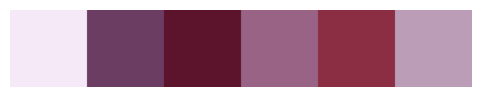

(245, 233, 247) white 74%
(107, 61, 98) purple 6%
(91, 20, 43) red 6%
(152, 99, 132) purple 6%
(140, 46, 67) red 5%
(188, 157, 183) purple 4%


In [ ]:
# testing
path = os.path.join(image_folder, "1.jpg")

cols, props = dominant_colours(path)
show_palette(cols, props)
for c, p in zip(cols, props):
    print(tuple(int(v) for v in c), classify_colour(c), f"{p*100:.0f}%")